# 4. OPE Estimator Diagnostics

This notebook builds the off-policy-evaluation (OPE) diagnostics used after the replay screen. Notebook 3 identified a replay shortlist and checked daily stability. Notebook 4 asks a different question: when we move from mechanical replay to model-assisted logged-data diagnostics, does the same policy remain credible, and how much support does that evidence have?

The notebook regenerates the OPE figures used in the paper:

- **Estimator comparison:** replay, direct method, IPS/SNIPS-style diagnostics, and doubly robust diagnostics.
- **Importance-weight diagnostics:** effective sample size and realized weight tails under the simulated logging setup.
- **Conservative lower-tail ranking:** lower-bound cross-fitted doubly robust evidence for shortlisted policies.

The MDE/validation-design figure is intentionally deferred to a later notebook, because it belongs near the launch-readiness section rather than immediately after replay.


## What This Notebook Creates

Inputs from earlier notebooks:

- `metadata/reserve_policy_effects.csv`
- `metadata/reserve_policy_candidate_handoff.csv`
- `metadata/season2_panel_manifest.csv`
- Season 2 panel shards under `data/processed/season2_bid_opportunity_panel/`
- `metadata/reserve_policy_price_landscape.csv`

Generated analysis artifacts include:

- `metadata/policy_validation_plan.csv`
- `metadata/auction_policy_ope_results.csv`
- `metadata/ope_weight_diagnostics.csv`
- `metadata/ope_clipping_sensitivity.csv`
- `metadata/crossfit_dr_policy_results.csv`
- `metadata/advanced_policy_conservative_ranking.csv`
- `metadata/conservative_ranking_comparison.csv`
- `metadata/marketplace_scorecard.csv`

Generated paper figures:

- `artifacts/figures/08_ope_estimator_comparison.png`
- `artifacts/figures/08_weight_diagnostics.png`
- `artifacts/figures/08_conservative_lower_bound_ranking.png`

Some additional downstream artifacts, such as heterogeneity summaries and scorecard handoff files, are created by the same OPE builder because later notebooks reuse them. This notebook focuses interpretation on the estimator and support evidence.


## Why Simulated-Logger OPE Is Needed

The public iPinYou logs do not contain randomized assignment probabilities for the candidate reserve/floor policies. That means ordinary inverse-propensity or doubly robust estimators cannot be treated as production-valid causal estimators for the original logs. The paper handles this carefully: OPE is run under an explicit simulated known-propensity logger inside the notebook workflow. The goal is diagnostic rather than launch authorization.

This design answers three useful questions:

1. Do replay-style and model-assisted estimates point in the same direction?
2. Are importance weights reasonably supported, or are estimates dominated by a few high-weight rows?
3. Does the priority policy remain attractive under lower-tail uncertainty rather than only under mean lift?

This is why OPE comes after replay. Replay supplies the candidate set; OPE audits whether the candidate set survives a more uncertainty-aware logged-data diagnostic.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing src/ and pyproject.toml")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Repository root: {REPO_ROOT}")


Repository root: /home/apex/Documents/ranking_sys/notebooks/writing/ads_marketplace_auction_experimentation/marketplace-policies-code


In [2]:
from IPython.display import Image, display

from checks import ArtifactRepository
from config import PaperConfig, ProjectPaths, RawPipelineConfig
from data_access import Workspace
from figures import FigureRenderer
from ope import OPEEvidenceBuilder
from policy_catalog import ReservePolicyCatalog
from progress import ProgressLogger


In [3]:
SOURCE_ROOT = REPO_ROOT / "artifacts" / "workspace"
OUTPUT_ROOT = REPO_ROOT / "artifacts"

paths = ProjectPaths.from_cli(SOURCE_ROOT, OUTPUT_ROOT)
paths.ensure_output_dirs()
repository = ArtifactRepository(paths)
repository.require_layout()
workspace = Workspace(paths.source_root)
progress = ProgressLogger(enabled=True)

required = [
    workspace.metadata_dir / "reserve_policy_effects.csv",
    workspace.metadata_dir / "reserve_policy_candidate_handoff.csv",
    workspace.metadata_dir / "season2_panel_manifest.csv",
    workspace.metadata_dir / "reserve_policy_price_landscape.csv",
]
missing = [path.relative_to(REPO_ROOT) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Run notebooks/0_setup.ipynb and notebooks/3_reserve_policy_tradeoff_and_daily_stability.ipynb first. "
        f"Missing: {missing}"
    )

print("Required replay and setup artifacts are present.")


Required replay and setup artifacts are present.


## Reconstruct the Policy Catalog and OPE Configuration

The OPE builder needs the same policy catalog used by replay. We reconstruct it from the positive-floor quantiles saved by setup. The values are not recomputed here; the point is to freeze the same policy definitions before running estimator diagnostics.


In [4]:
price_landscape = repository.read_csv("reserve_policy_price_landscape.csv")
price_values = price_landscape.set_index("stat")["value"].to_dict()
price_quantiles = {
    "q25": float(price_values["positive_floor_q25"]),
    "q50": float(price_values["positive_floor_q50"]),
    "q75": float(price_values["positive_floor_q75"]),
}

catalog = ReservePolicyCatalog(price_quantiles)
policy_registry = catalog.registry()
policy_registry[["policy_number", "policy_id", "policy_family", "floor_rule"]]


,policy_number,policy_id,policy_family,floor_rule
0,P0,logged_floor_status_quo,baseline,logged
1,P1,uniform_raise_05pct,uniform_percent,logged * 1.05
2,P2,uniform_raise_10pct,uniform_percent,logged * 1.10
3,P3,uniform_raise_15pct,uniform_percent,logged * 1.15
4,P4,uniform_raise_20pct,uniform_percent,logged * 1.20
5,P5,uniform_raise_30pct,uniform_percent,logged * 1.30
6,P6,add_5_all_floors,absolute_increment,logged + 5
7,P7,add_10_all_floors,absolute_increment,logged + 10
8,P8,add_20_all_floors,absolute_increment,logged + 20
9,P9,min_positive_floor_q25,minimum_positive_floor,"max(logged, 10.00) if logged > 0"


In [5]:
config = RawPipelineConfig(
    data_root=REPO_ROOT / "data",
    workspace_root=SOURCE_ROOT,
    full_run=True,
    clean_workspace=False,
)

print("OPE configuration:")
print(f"  rows_per_day_for_ope_sample: {config.rows_per_day_for_ope_sample:,}")
print(f"  max_model_train_rows: {config.max_model_train_rows:,}")
print(f"  max_model_eval_rows: {config.max_model_eval_rows:,}")
print(f"  advanced_cf_rows: {config.advanced_cf_rows:,}")
print(f"  advanced_bootstraps: {config.advanced_bootstraps:,}")


OPE configuration:
  rows_per_day_for_ope_sample: 100,000
  max_model_train_rows: 250,000
  max_model_eval_rows: 300,000
  advanced_cf_rows: 240,000
  advanced_bootstraps: 300


## Run OPE Diagnostics

Set `RUN_OPE = True` for a fresh run. The OPE builder samples rows from each Season 2 shard, simulates a known-propensity logger over the shortlisted policies, fits a gradient-boosting outcome model, computes replay/direct-method/IPS/SNIPS/doubly robust diagnostics, and then runs cross-fitted DR with cluster bootstrap lower-tail ranking.

This can take a while because it trains several models and performs bootstrap ranking. Set `RUN_OPE = False` only when the artifacts already exist and you only want to rerender figures or inspect tables.


In [6]:
RUN_OPE = True

builder = OPEEvidenceBuilder(workspace, config, catalog, progress=progress)

if RUN_OPE:
    # This creates policy_validation_plan.csv as a prerequisite for the OPE scorecard.
    # The validation-design/MDE figure from this artifact is rendered in a later notebook.
    builder.build_experiment_design()
    scorecard = builder.build_ope_and_scorecard()
    # Refresh validation-design metadata now that scorecard quantities exist.
    # We still defer the MDE figure itself to the launch-readiness notebook.
    builder.build_experiment_design()
else:
    scorecard = repository.read_csv("marketplace_scorecard.csv")

print(f"Scorecard rows: {len(scorecard):,}")
scorecard[["policy_id", "weighted_evidence_score", "crossfit_dr_pct_lift_p10", "policy_decision"]].head(10)


[    21.6s] Starting: experiment-design and validation-plan artifacts
[    21.6s] Finished: experiment-design artifacts; 16 candidate validation row(s)
[    21.6s] Starting: simulated-logger OPE, cross-fitted DR, ranking, and scorecard
[    21.8s] Selected 7 policies for OPE diagnostics.
[    21.8s] Starting: constructing OPE sample from 7 season-two panel shard(s)
[    21.8s] Sampling OPE rows from season2_panel_20130606.parquet.
[    22.8s] Sampling OPE rows from season2_panel_20130607.parquet.
[    23.9s] Sampling OPE rows from season2_panel_20130608.parquet.
[    24.3s] Sampling OPE rows from season2_panel_20130609.parquet.
[    25.7s] Sampling OPE rows from season2_panel_20130610.parquet.
[    26.2s] Sampling OPE rows from season2_panel_20130611.parquet.
[    26.7s] Sampling OPE rows from season2_panel_20130612.parquet.
[    27.2s] Finished: OPE sample construction; materialized 700,000 rows
[    27.2s] Building policy floor and structural replay matrices for 700,000 OPE rows.
[  

,policy_id,weighted_evidence_score,crossfit_dr_pct_lift_p10,policy_decision
0,hybrid_q75_if_gap_100,4.305,0.458253,priority_shadow_log_then_switchback
1,min_positive_floor_q75,4.205,0.282295,priority_shadow_log_then_switchback
3,hybrid_q50_if_gap_50,3.635,0.075046,priority_shadow_log_then_switchback
4,margin_gap_100_add_20,3.635,0.051537,priority_shadow_log_then_switchback
5,add_20_all_floors,3.635,0.066209,priority_shadow_log_then_switchback
2,zero_and_low_floor_to_q50,3.585,0.069217,priority_shadow_log_then_switchback
6,min_positive_floor_q50,2.535,NaN,priority_shadow_log_then_switchback
9,margin_gap_50_add_10,2.535,NaN,priority_shadow_log_then_switchback
10,add_10_all_floors,2.535,NaN,priority_shadow_log_then_switchback
7,uniform_raise_30pct,2.385,NaN,priority_shadow_log_then_switchback


The scorecard is produced here because the OPE layer creates the conservative ranking and handoff variables that later notebooks need. At this stage, however, we should not over-interpret the final scorecard as a launch decision. The immediate question is narrower: do the OPE estimators and support diagnostics reinforce or weaken the replay shortlist?


## Estimator Comparison Inputs

The estimator comparison table aligns the full-panel replay lift with the conservative lower-tail DR lift. The key policy-level question is whether the priority policy remains favorable after moving from a mechanical replay mean to a lower-tail model-assisted diagnostic.


In [7]:
comparison = repository.read_csv("conservative_ranking_comparison.csv")
comparison.merge(
    policy_registry[["policy_id", "policy_number", "policy_label"]],
    on="policy_id",
    how="left",
)[[
    "policy_number",
    "policy_label",
    "policy_id",
    "pct_delta_yield_per_opportunity_vs_baseline",
    "crossfit_dr_pct_lift_p10",
    "weighted_evidence_score",
]].sort_values("weighted_evidence_score", ascending=False)


,policy_number,policy_label,policy_id,pct_delta_yield_per_opportunity_vs_baseline,crossfit_dr_pct_lift_p10,weighted_evidence_score
0,P18,Q75 Margin-Gated Floor,hybrid_q75_if_gap_100,0.476604,0.458253,4.305
1,P11,Min Positive Floor Q75,min_positive_floor_q75,0.355075,0.282295,4.205
2,P17,Hybrid Q50 If Gap 50,hybrid_q50_if_gap_50,0.101179,0.075046,3.635
3,P16,Margin Gap 100 Add 20,margin_gap_100_add_20,0.097883,0.051537,3.635
4,P8,Add 20 All Floors,add_20_all_floors,0.097433,0.066209,3.635
5,P13,Zero And Low Floor To Q50,zero_and_low_floor_to_q50,0.101179,0.069217,3.585
6,P10,Min Positive Floor Q50,min_positive_floor_q50,0.072978,NaN,2.535
7,P15,Margin Gap 50 Add 10,margin_gap_50_add_10,0.040727,NaN,2.535
8,P7,Add 10 All Floors,add_10_all_floors,0.040310,NaN,2.535
9,P5,Uniform Raise 30Pct,uniform_raise_30pct,0.069190,NaN,2.385


## OPE Figure: Estimator Comparison

This figure compares the replay mean with the conservative lower-tail doubly robust diagnostic. The purpose is to detect whether the recommendation depends entirely on one estimator family. Agreement does not make the result launch-ready, but it strengthens the case that the priority policy deserves validation capacity.


Wrote OPE estimator comparison to artifacts/figures/08_ope_estimator_comparison.png


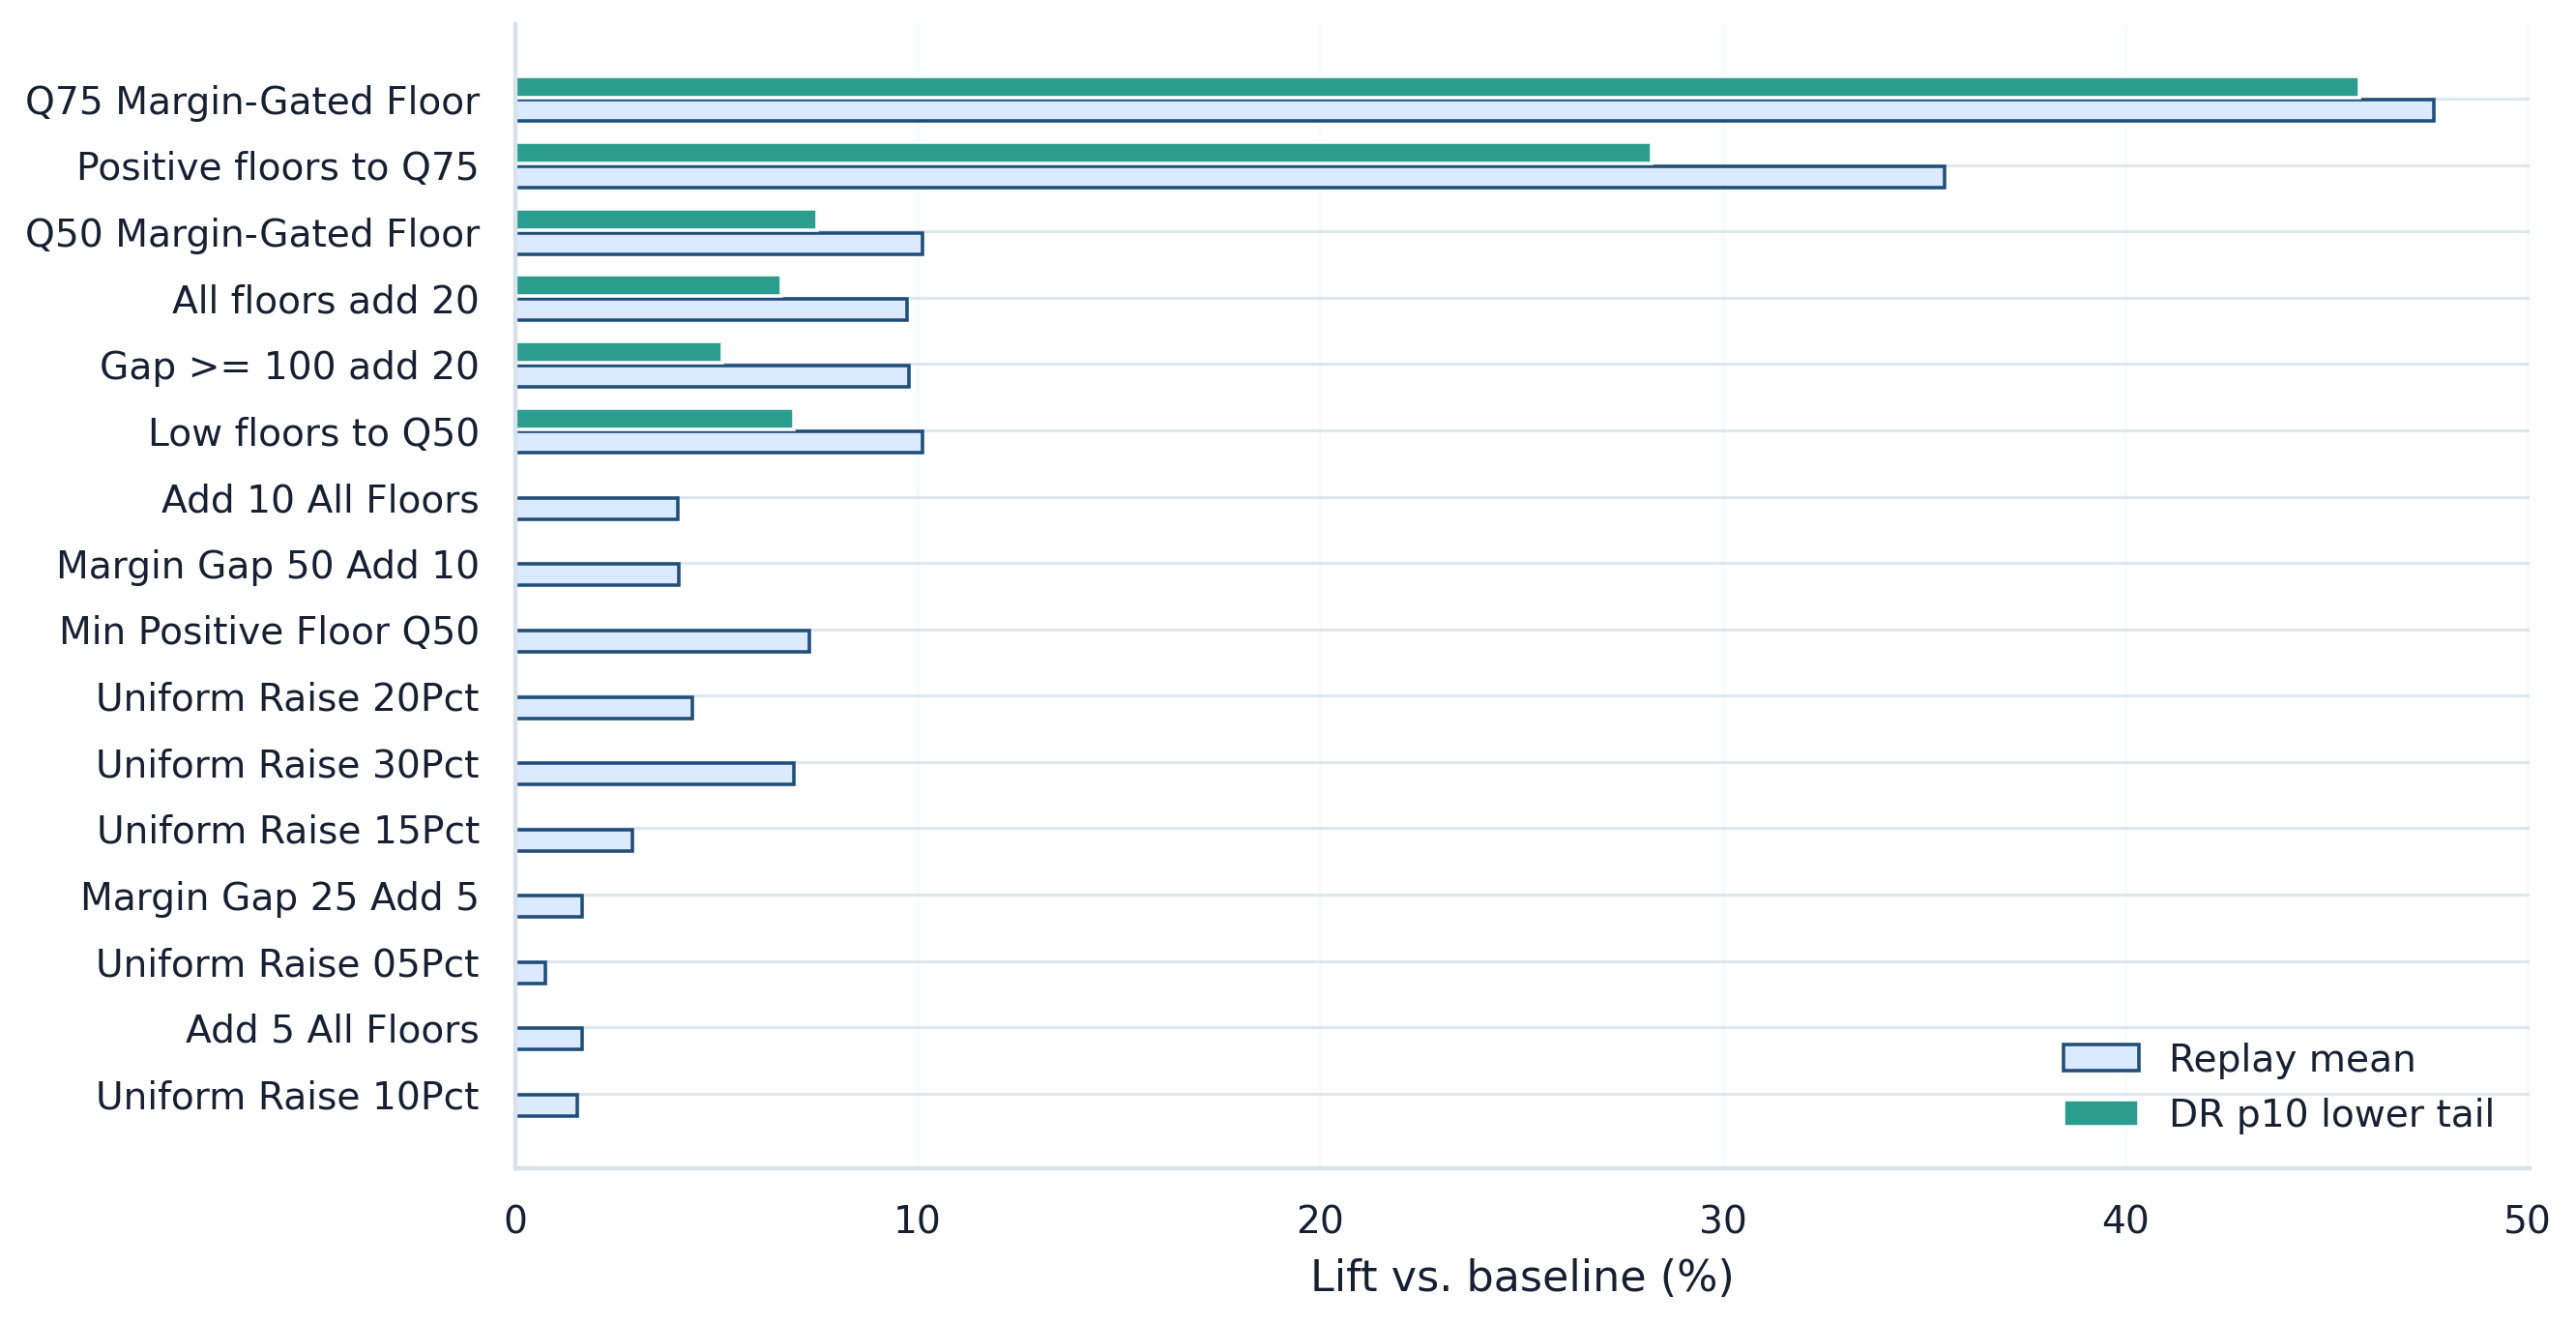

In [8]:
renderer = FigureRenderer(repository, paths.figure_dir, PaperConfig(), progress=progress)
ope_comparison_path = renderer.plot_ope_comparison()
print(f"Wrote OPE estimator comparison to {ope_comparison_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(ope_comparison_path)))


## Importance-Weight Diagnostics

Importance weights are the support diagnostic behind OPE. If the target policy is rarely observed under the simulated logger, inverse-propensity weights become large and the effective sample size becomes small. In that case, a favorable mean estimate is less trustworthy because it may be driven by a small number of influential observations.


In [9]:
weights = repository.read_csv("ope_weight_diagnostics.csv")
weights.merge(
    policy_registry[["policy_id", "policy_number", "policy_label"]],
    on="policy_id",
    how="left",
)[[
    "policy_number",
    "policy_label",
    "policy_id",
    "assignment_rate_for_target",
    "effective_sample_size_ratio",
    "realized_weight_p99",
    "share_realized_weight_gt_10",
]].sort_values("effective_sample_size_ratio")


,policy_number,policy_label,policy_id,assignment_rate_for_target,effective_sample_size_ratio,realized_weight_p99,share_realized_weight_gt_10
1,P18,Q75 Margin-Gated Floor,hybrid_q75_if_gap_100,0.060003,0.059426,19.043574,1.000000
2,P11,Min Positive Floor Q75,min_positive_floor_q75,0.073587,0.072787,15.885777,1.000000
4,P17,Hybrid Q50 If Gap 50,hybrid_q50_if_gap_50,0.110357,0.110097,9.991174,0.000000
3,P13,Zero And Low Floor To Q50,zero_and_low_floor_to_q50,0.110630,0.110371,9.991174,0.000000
5,P16,Margin Gap 100 Add 20,margin_gap_100_add_20,0.113527,0.113392,9.384623,0.000000
6,P8,Add 20 All Floors,add_20_all_floors,0.114040,0.113873,9.384623,0.004501
0,P0,Logged Floor Status Quo,logged_floor_status_quo,0.417857,0.417568,2.477486,0.000000


## OPE Figure: Weight Diagnostics

The weight-diagnostics figure reports effective sample size ratio and the 99th percentile realized weight. This is not a cosmetic robustness plot. It determines how much weight the decision system should place on the OPE layer. Poor support does not negate replay, but it prevents the OPE estimate from becoming a direct-launch justification.


Wrote weight diagnostics to artifacts/figures/08_weight_diagnostics.png


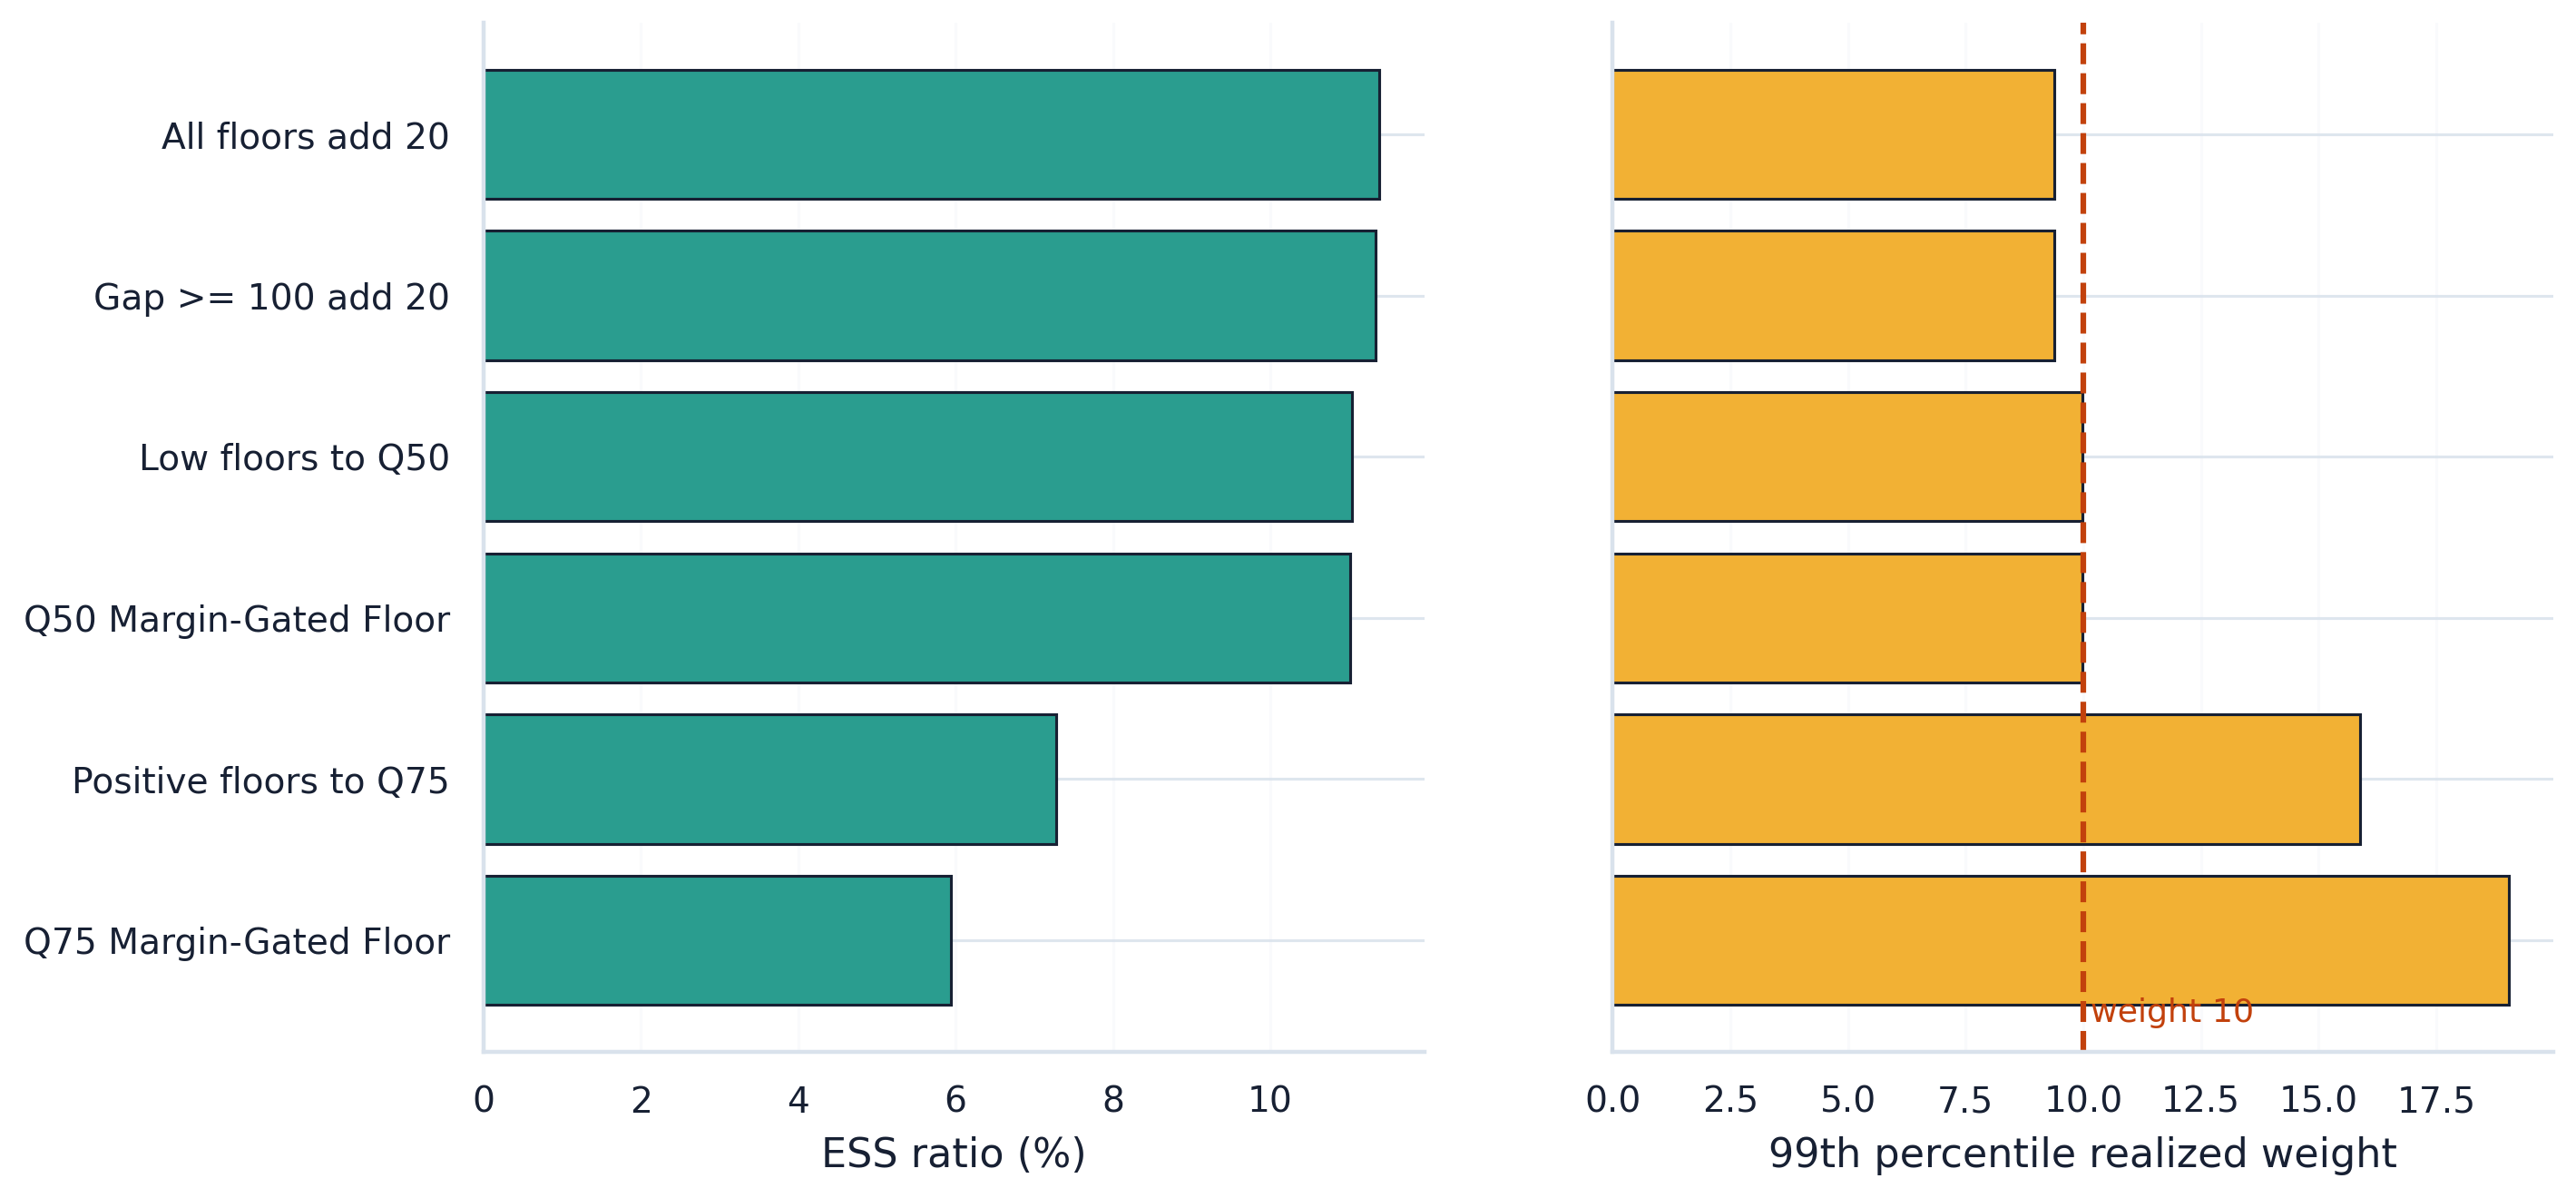

In [10]:
weight_path = renderer.plot_weight_diagnostics()
print(f"Wrote weight diagnostics to {weight_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(weight_path)))


## Conservative Lower-Tail Ranking

The final diagnostic in this notebook ranks candidate policies by lower-tail cross-fitted DR evidence rather than by mean replay lift alone. This is aligned with the decision problem: a platform usually does not need the highest optimistic point estimate; it needs a policy whose downside-adjusted evidence is strong enough to justify an online validation test.


In [11]:
ranking = repository.read_csv("advanced_policy_conservative_ranking.csv")
ranking.merge(
    policy_registry[["policy_id", "policy_number", "policy_label"]],
    on="policy_id",
    how="left",
)[[
    "policy_number",
    "policy_label",
    "policy_id",
    "crossfit_dr_pct_lift_p10",
    "crossfit_dr_pct_lift_p50",
    "crossfit_dr_pct_lift_p90",
    "crossfit_dr_pr_lift_positive",
    "conservative_rank",
]].sort_values("conservative_rank")


,policy_number,policy_label,policy_id,crossfit_dr_pct_lift_p10,crossfit_dr_pct_lift_p50,crossfit_dr_pct_lift_p90,crossfit_dr_pr_lift_positive,conservative_rank
1,P18,Q75 Margin-Gated Floor,hybrid_q75_if_gap_100,0.458253,0.486662,0.513873,1.0,1.0
2,P11,Min Positive Floor Q75,min_positive_floor_q75,0.282295,0.317906,0.350872,1.0,2.0
4,P17,Hybrid Q50 If Gap 50,hybrid_q50_if_gap_50,0.075046,0.093154,0.107308,1.0,3.0
3,P13,Zero And Low Floor To Q50,zero_and_low_floor_to_q50,0.069217,0.087086,0.104778,1.0,4.0
6,P8,Add 20 All Floors,add_20_all_floors,0.066209,0.083346,0.100398,1.0,5.0
5,P16,Margin Gap 100 Add 20,margin_gap_100_add_20,0.051537,0.073661,0.096127,1.0,6.0
0,P0,Logged Floor Status Quo,logged_floor_status_quo,0.000000,0.000000,0.000000,0.0,NaN


## OPE Figure: Conservative Lower-Bound Ranking

This figure shows whether the priority policy remains attractive after the decision rule penalizes uncertainty. A positive lower-tail estimate is stronger evidence than a favorable mean because it asks whether the policy remains promising across bootstrap resamples of exchange-hour market clusters.


Wrote conservative ranking to artifacts/figures/08_conservative_lower_bound_ranking.png


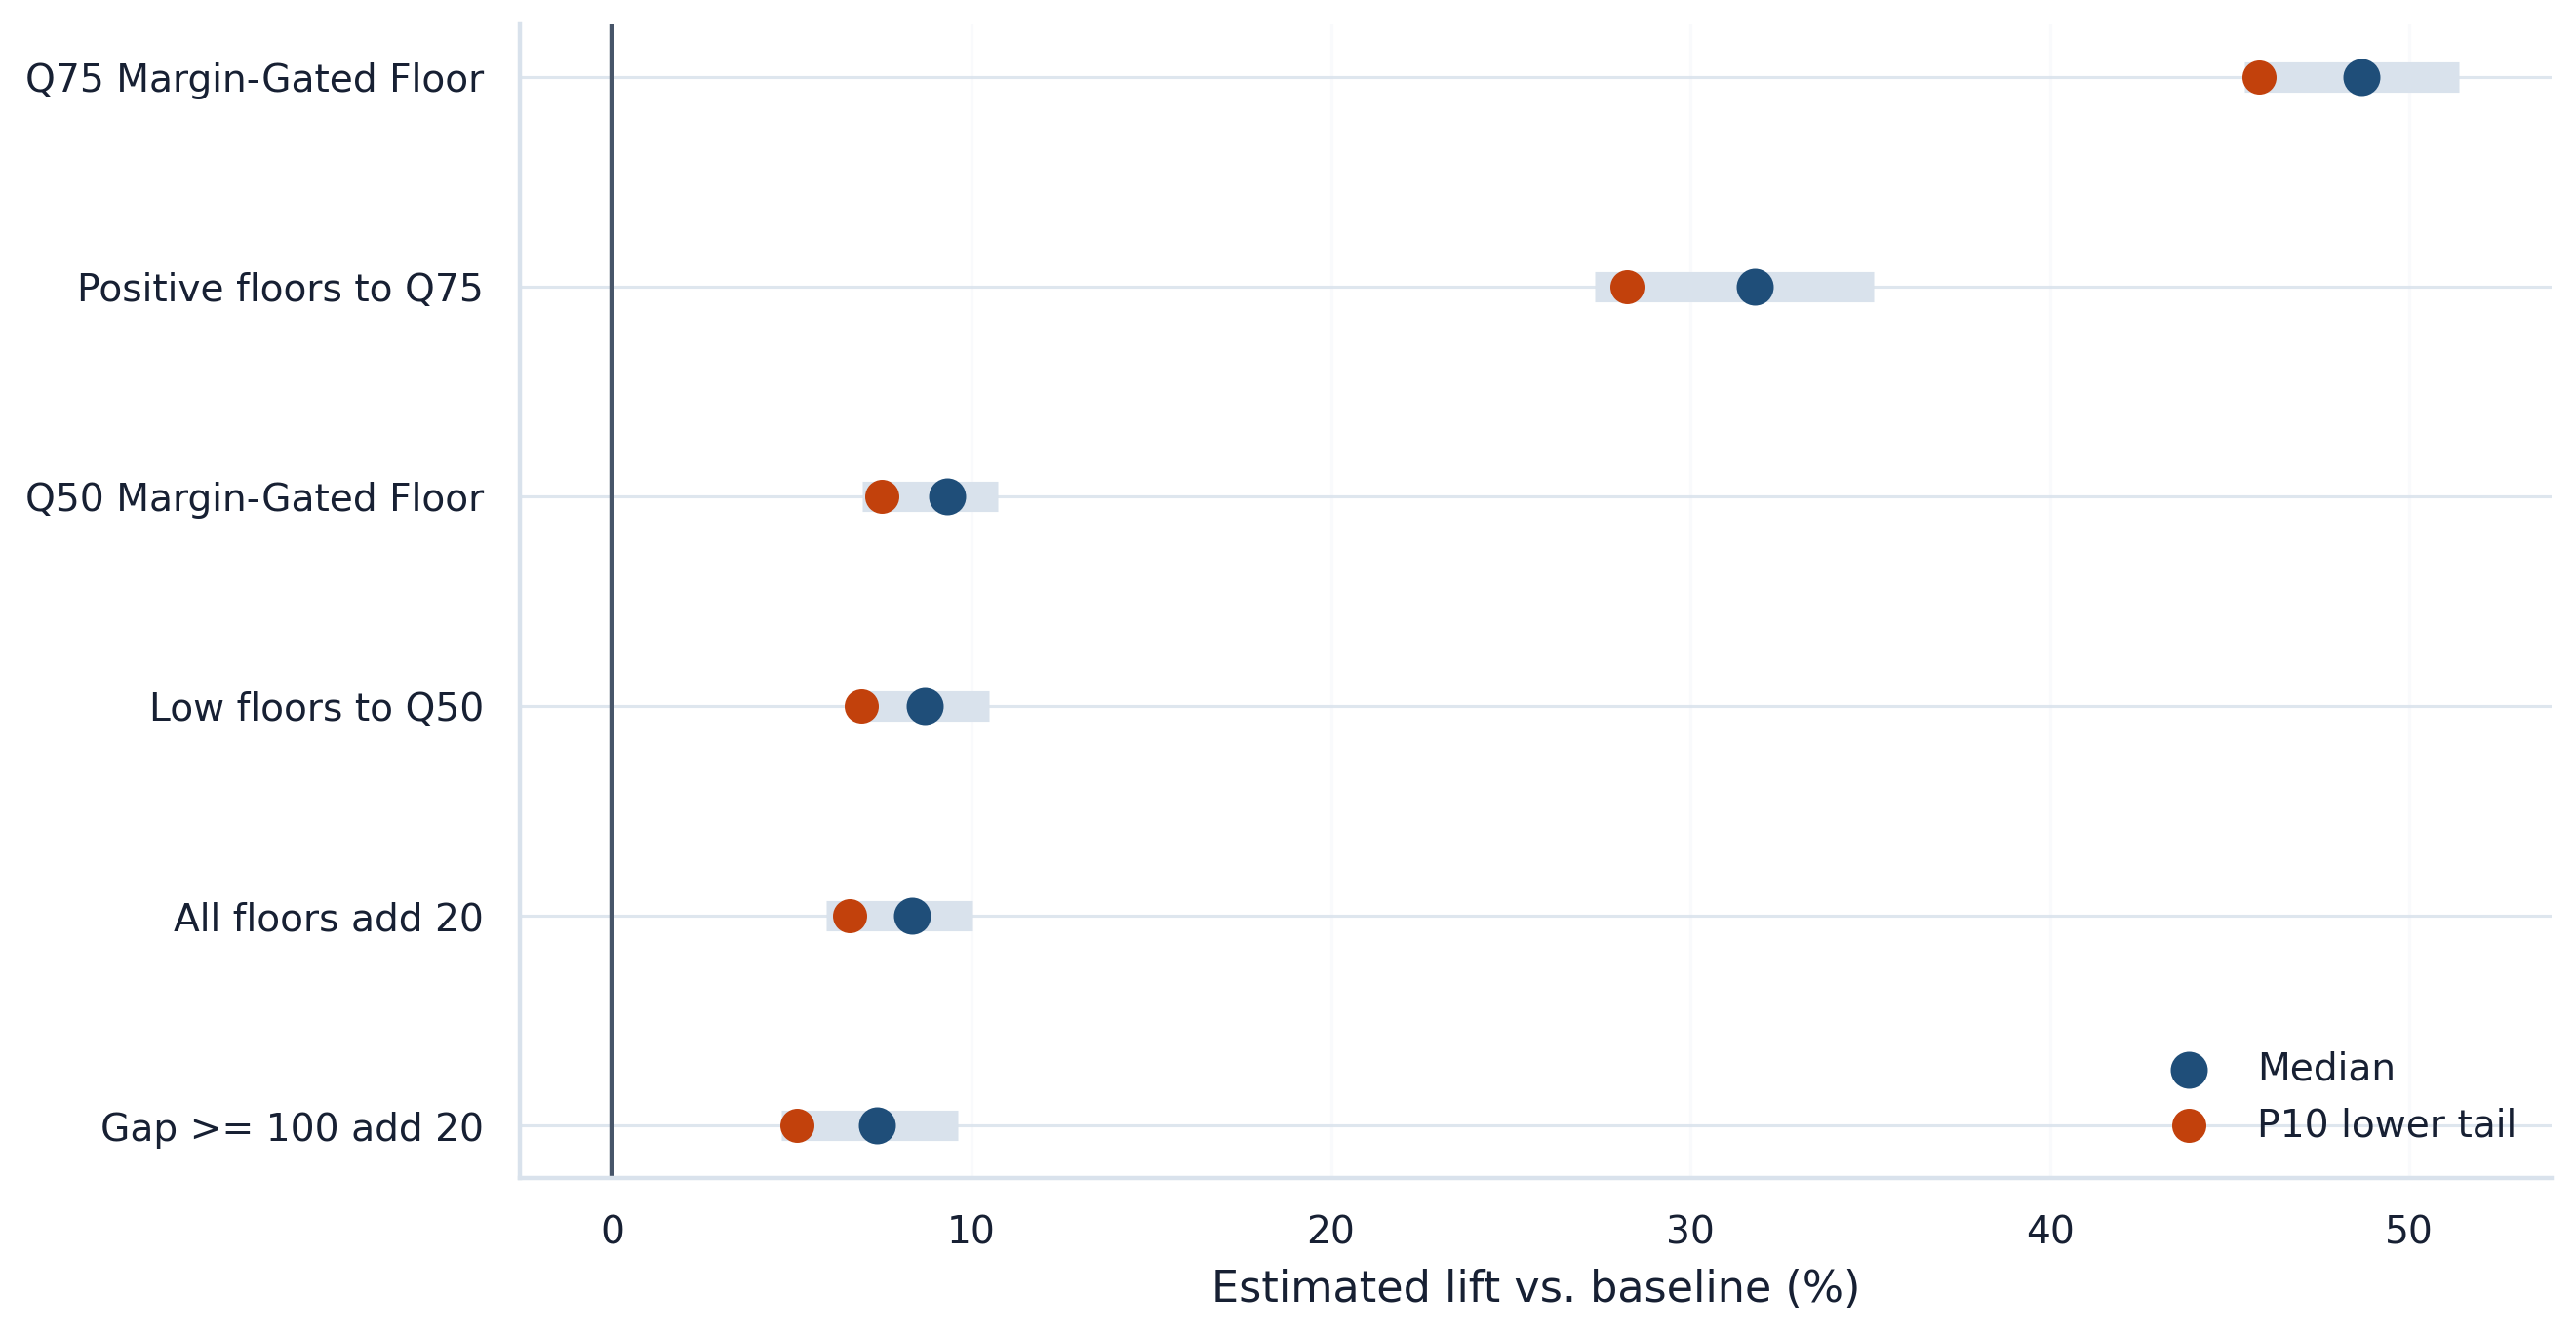

In [12]:
ranking_path = renderer.plot_conservative_ranking()
print(f"Wrote conservative ranking to {ranking_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(ranking_path)))


## Interpretation for the Paper

Notebook 4 changes the empirical status of the priority policy. After notebook 3, the policy is a strong replay candidate. After this notebook, the policy is also supported by model-assisted diagnostics under an explicit simulated known-propensity setup. The estimator comparison checks that the result is not purely a replay artifact. The weight diagnostics show how much support the simulated OPE layer has. The conservative ranking asks whether the policy remains attractive under lower-tail uncertainty rather than only under mean lift.

The interpretation remains deliberately conservative. These OPE outputs do not replace a production experiment because the public logs do not contain real randomized propensities for the candidate policies and do not observe live bidder response. Their role is to decide whether the replay leader deserves deeper validation, not to authorize launch. The next empirical layers should therefore study heterogeneity, response/sensitivity, out-of-time Season 3 validation, and the final launch-readiness gates.
